<a href="https://colab.research.google.com/github/IamPriyabrato04/custom-agent/blob/main/vit_leaf_disease_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leaf Disease ViT Training Notebook

This notebook downloads the leaf disease dataset from Google Drive, ignores the existing 7:2:1 split, creates a leakage-safe 8:1:1 split, and fine-tunes a Vision Transformer.

Important choices used here:
- Exact duplicate images are removed.
- Near-duplicate or same-leaf-looking images are kept, but grouped into the same split.
- Only necessary image processing is used before training.
- Training runs for at least 7 epochs and at most 20 epochs, with early stopping patience of 3.
- The notebook works best on Colab TPU or T4 GPU.

## 1. Install Dependencies

Run this cell first in Google Colab. If you use a TPU runtime and `torch_xla` is missing, run the commented TPU install line, then restart the runtime.

In [1]:
%pip -q install gdown transformers accelerate scikit-learn pandas pillow imagehash matplotlib seaborn tqdm torchvision

# For a Colab TPU runtime only, uncomment this if importing torch_xla fails later.
%pip -q install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 129.0 MB/s eta 0:00:00


## 2. Configuration

These are the main values you may want to change. The defaults are chosen for your dataset size and free-tier Colab.

In [2]:
from pathlib import Path

FILE_ID = '1zV6XfeCCMnLZV8ilw6jFTg6yjvbKGLK_'
PROJECT_DIR = Path('/content/leaf-disease-vit')

ZIP_PATH = PROJECT_DIR / 'data' / 'leaf_disease.zip'
RAW_DIR = PROJECT_DIR / 'data' / 'raw'
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
AUDIT_DIR = PROJECT_DIR / 'outputs' / 'data_audit'
MODEL_DIR = PROJECT_DIR / 'outputs' / 'vit_leaf_disease'

MODEL_NAME = 'google/vit-base-patch16-224-in21k'
IMAGE_SIZE = 224

# Your requested epoch policy.
MIN_EPOCHS = 7
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3

# Safe defaults for Colab free-tier TPU/T4. If T4 runs out of memory, set this to 16.
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
SEED = 42

# Same-leaf grouping thresholds. Increase EMBEDDING_SIMILARITY_THRESHOLD if grouping is too aggressive.
PHASH_DISTANCE_THRESHOLD = 6
EMBEDDING_SIMILARITY_THRESHOLD = 0.97

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

for directory in [PROJECT_DIR, ZIP_PATH.parent, RAW_DIR, PROCESSED_DIR, AUDIT_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f'Project folder: {PROJECT_DIR}')

Project folder: /content/leaf-disease-vit


## 3. Imports and Reproducibility

In [3]:
import csv
import hashlib
import json
import math
import os
import sys
import random
import shutil
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass

import gdown
import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image, ImageOps, UnidentifiedImageError
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

try:
    from transformers import AutoImageProcessor, AutoModelForImageClassification, get_cosine_schedule_with_warmup
except ImportError as e:
    print(f"Warning: Transformers import failed due to XLA incompatibility: {e}")
    print("Applying fallback: Masking torch_xla to allow standard import.")
    # Temporarily hide torch_xla from the system to prevent transformers from triggering the broken binary
    _real_xla = sys.modules.get('torch_xla')
    sys.modules['torch_xla'] = None
    try:
        from transformers import AutoImageProcessor, AutoModelForImageClassification, get_cosine_schedule_with_warmup
    finally:
        if _real_xla:
            sys.modules['torch_xla'] = _real_xla
        else:
            del sys.modules['torch_xla']

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## 4. Detect TPU, GPU, or CPU

TPU is preferred if Colab exposes `torch_xla`. If not, the notebook automatically falls back to CUDA GPU and then CPU.

In [4]:
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    XLA_AVAILABLE = True
except Exception:
    torch_xla = None
    xm = None
    XLA_AVAILABLE = False

if XLA_AVAILABLE:
    DEVICE = xm.xla_device()
    DEVICE_KIND = 'TPU/XLA'
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    DEVICE_KIND = 'CUDA GPU'
else:
    DEVICE = torch.device('cpu')
    DEVICE_KIND = 'CPU'

print(f'Using device: {DEVICE_KIND} ({DEVICE})')

Using device: TPU/XLA (xla:0)


/tmp/ipykernel_958/3672381553.py:11: DeprecationWarning: Use torch_xla.device instead
  DEVICE = xm.xla_device()


## 5. Download and Extract the Dataset

In [5]:
def download_from_drive(file_id: str, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f'ZIP already exists: {output_path}')
        return

    print('Downloading dataset from Google Drive...')
    gdown.download(id=file_id, output=str(output_path), quiet=False)

def safe_extract_zip(zip_path: Path, extract_to: Path) -> None:
    extract_to.mkdir(parents=True, exist_ok=True)
    destination = extract_to.resolve()

    with zipfile.ZipFile(zip_path, 'r') as zip_file:
        for member in zip_file.infolist():
            target_path = (extract_to / member.filename).resolve()
            if not str(target_path).startswith(str(destination)):
                raise RuntimeError(f'Unsafe path inside ZIP: {member.filename}')
        zip_file.extractall(extract_to)

    print(f'Extracted dataset to: {extract_to}')

download_from_drive(FILE_ID, ZIP_PATH)
safe_extract_zip(ZIP_PATH, RAW_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1zV6XfeCCMnLZV8ilw6jFTg6yjvbKGLK_
From (redirected): https://drive.google.com/uc?id=1zV6XfeCCMnLZV8ilw6jFTg6yjvbKGLK_&confirm=t&uuid=f50f9585-7166-4339-8251-bebccc77e1d3
To: /content/leaf-disease-vit/data/leaf_disease.zip
100%|██████████| 537M/537M [00:03<00:00, 135MB/s] 


Extracted dataset to: /content/leaf-disease-vit/data/raw


## 6. Read Images, Ignore Old Split, and Validate Files

This step merges the old train/validation/test folders logically. It does not trust the existing 7:2:1 split.

In [6]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
SPLIT_NAMES = {'train', 'training', 'val', 'valid', 'validation', 'test', 'testing'}

@dataclass
class ImageRecord:
    path: Path
    label: str
    sha256: str = ''
    phash: str = ''
    group_id: str = ''

def infer_label_from_path(image_path: Path, root: Path) -> str:
    relative_parts = image_path.relative_to(root).parts

    # If the path contains an old split folder, the next folder is treated as the class.
    for index, part in enumerate(relative_parts[:-1]):
        if part.lower() in SPLIT_NAMES and index + 1 < len(relative_parts) - 1:
            return relative_parts[index + 1]

    # Otherwise the direct parent folder is treated as the class.
    return image_path.parent.name

def find_images(root: Path) -> list[ImageRecord]:
    records = []
    for path in root.rglob('*'):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            label = infer_label_from_path(path, root)
            records.append(ImageRecord(path=path, label=label))
    return records

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as file:
        for chunk in iter(lambda: file.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

def load_clean_rgb(path: Path) -> Image.Image:
    image = Image.open(path)
    image = ImageOps.exif_transpose(image)
    return image.convert('RGB')

def validate_and_hash(records: list[ImageRecord]) -> tuple[list[ImageRecord], pd.DataFrame]:
    valid_records = []
    bad_rows = []

    for record in tqdm(records, desc='Validating images'):
        try:
            with load_clean_rgb(record.path) as image:
                record.phash = str(imagehash.phash(image))
            record.sha256 = sha256_file(record.path)
            valid_records.append(record)
        except (UnidentifiedImageError, OSError, ValueError) as error:
            bad_rows.append({'path': str(record.path), 'label': record.label, 'error': str(error)})

    return valid_records, pd.DataFrame(bad_rows)

raw_records = find_images(RAW_DIR)
print(f'Found {len(raw_records):,} image files before cleaning.')

valid_records, corrupt_df = validate_and_hash(raw_records)
corrupt_df.to_csv(AUDIT_DIR / 'corrupt_images.csv', index=False)

print(f'Valid images: {len(valid_records):,}')
print(f'Corrupt/unreadable images: {len(corrupt_df):,}')
print(pd.Series([record.label for record in valid_records]).value_counts().sort_index())

Found 50,053 image files before cleaning.


Validating images:   0%|          | 0/50053 [00:00<?, ?it/s]

Valid images: 50,053
Corrupt/unreadable images: 0
Apple_Apple_scab                            2014
Apple__Apple__rot                           1987
Apple___Cedar_apple_rust                    1760
Apple__healthy                              2000
Blueberry_healthy                           1816
Cherry_healthy                              1826
Cherry_including_sour__Powdery_mildew       1683
Corn_maize_Northern_Leaf_Blight             1908
Grape___Leaf_blight_Isariopsis_Leaf_Spot    1722
Grape___healthy                             1692
Orange_Haunglongbing_Citrus_greening        2010
Peach___Bacterial_spot                      1838
Peach___healthy                             1728
Pepper_bell___Bacterial_spot                1913
Potato___Early_blight                       1939
Potato___healthy                            1824
Rasberry_healthy                            1781
Soybean___healthy                           2022
Squash___Powdery_mildew                     1736
Tomato_Bacterial_sp

## 7. Remove Exact Duplicates

Exact duplicate files are removed from the training pool. Near-duplicates are handled later by grouping, not deletion.

In [7]:
def remove_exact_duplicates(records: list[ImageRecord]) -> tuple[list[ImageRecord], pd.DataFrame]:
    first_seen = {}
    unique_records = []
    duplicate_rows = []

    for record in records:
        if record.sha256 not in first_seen:
            first_seen[record.sha256] = record
            unique_records.append(record)
        else:
            kept = first_seen[record.sha256]
            duplicate_rows.append({
                'removed_path': str(record.path),
                'kept_path': str(kept.path),
                'label': record.label,
                'sha256': record.sha256,
            })

    return unique_records, pd.DataFrame(duplicate_rows)

unique_records, exact_duplicates_df = remove_exact_duplicates(valid_records)
exact_duplicates_df.to_csv(AUDIT_DIR / 'exact_duplicates.csv', index=False)

print(f'Images after exact duplicate removal: {len(unique_records):,}')
print(f'Exact duplicates removed: {len(exact_duplicates_df):,}')

Images after exact duplicate removal: 50,039
Exact duplicates removed: 14


## 8. Group Same-Leaf or Near-Duplicate Images

This section uses two signals:
- Perceptual hash distance catches visually near-identical images.
- ResNet image embeddings catch similar images captured from different angles.

The groups are used only for splitting. Same-leaf images are not deleted.

In [8]:
import time

class UnionFind:
    def __init__(self, items):
        self.parent = {item: item for item in items}
        self.rank = {item: 0 for item in items}

    def find(self, item):
        while self.parent[item] != item:
            self.parent[item] = self.parent[self.parent[item]]
            item = self.parent[item]
        return item

    def union(self, left, right):
        left_root = self.find(left)
        right_root = self.find(right)

        if left_root == right_root:
            return

        if self.rank[left_root] < self.rank[right_root]:
            self.parent[left_root] = right_root
        elif self.rank[left_root] > self.rank[right_root]:
            self.parent[right_root] = left_root
        else:
            self.parent[right_root] = left_root
            self.rank[left_root] += 1


class EmbeddingDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image = load_clean_rgb(self.records[index].path)
        image = self.transform(image)
        return image


def build_embedding_model(device: torch.device) -> nn.Module:
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    model.fc = nn.Identity()
    model.eval()
    return model.to(device)


embedding_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def build_cache_metadata(records: list[ImageRecord]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            'path': str(record.path),
            'label': record.label,
            'sha256': record.sha256,
            'phash': record.phash,
        }
        for record in records
    ])


def cache_is_valid(records: list[ImageRecord], metadata_path: Path, embedding_path: Path) -> bool:
    if not metadata_path.exists() or not embedding_path.exists():
        return False

    old_metadata = pd.read_csv(metadata_path)
    new_metadata = build_cache_metadata(records)

    if len(old_metadata) != len(new_metadata):
        return False

    return old_metadata.equals(new_metadata)


def compute_embeddings_cached(
    records: list[ImageRecord],
    device: torch.device,
    batch_size: int = 128,
) -> np.ndarray:
    embedding_path = AUDIT_DIR / 'embedding_cache.npy'
    metadata_path = AUDIT_DIR / 'embedding_cache_metadata.csv'

    if cache_is_valid(records, metadata_path, embedding_path):
        print('Loading cached image embeddings...')
        return np.load(embedding_path)

    print('Computing image embeddings...')
    model = build_embedding_model(device)

    dataset = EmbeddingDataset(records, embedding_transform)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    all_embeddings = []

    with torch.inference_mode():
        for batch in tqdm(loader, desc='Embedding images'):
            batch = batch.to(device)
            embeddings = model(batch).detach().cpu().numpy()
            all_embeddings.append(embeddings)

    embeddings = np.concatenate(all_embeddings, axis=0)
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True).clip(min=1e-12)
    embeddings = embeddings / norms

    np.save(embedding_path, embeddings)
    build_cache_metadata(records).to_csv(metadata_path, index=False)

    print(f'Saved embedding cache to: {embedding_path}')
    return embeddings


def phash_to_binary_vector(phash_string: str) -> np.ndarray:
    phash = imagehash.hex_to_hash(phash_string)
    return np.asarray(phash.hash, dtype=np.uint8).reshape(-1)


def group_by_phash_fast(records, grouped_by_label, union_find):
    radius = PHASH_DISTANCE_THRESHOLD / 64.0

    for label, indices in tqdm(grouped_by_label.items(), desc='Grouping by pHash'):
        if len(indices) < 2:
            continue

        hash_vectors = np.stack([
            phash_to_binary_vector(records[index].phash)
            for index in indices
        ])

        neighbors = NearestNeighbors(
            metric='hamming',
            radius=radius,
            algorithm='brute',
        )
        neighbors.fit(hash_vectors)

        neighbor_lists = neighbors.radius_neighbors(
            hash_vectors,
            return_distance=False,
        )

        for local_index, neighbor_list in enumerate(neighbor_lists):
            source_index = indices[local_index]

            for neighbor_local_index in neighbor_list:
                target_index = indices[int(neighbor_local_index)]

                if source_index != target_index:
                    union_find.union(source_index, target_index)


def group_by_embeddings_fast(records, grouped_by_label, union_find, embeddings):
    radius = 1.0 - EMBEDDING_SIMILARITY_THRESHOLD

    for label, indices in tqdm(grouped_by_label.items(), desc='Grouping by embeddings'):
        if len(indices) < 2:
            continue

        label_embeddings = embeddings[indices]

        neighbors = NearestNeighbors(
            metric='cosine',
            radius=radius,
            algorithm='brute',
        )
        neighbors.fit(label_embeddings)

        neighbor_lists = neighbors.radius_neighbors(
            label_embeddings,
            return_distance=False,
        )

        for local_index, neighbor_list in enumerate(neighbor_lists):
            source_index = indices[local_index]

            for neighbor_local_index in neighbor_list:
                target_index = indices[int(neighbor_local_index)]

                if source_index != target_index:
                    union_find.union(source_index, target_index)


def group_similar_images(records: list[ImageRecord]) -> pd.DataFrame:
    start_time = time.time()

    grouped_by_label = defaultdict(list)
    for index, record in enumerate(records):
        grouped_by_label[record.label].append(index)

    union_find = UnionFind(range(len(records)))

    print('Step 1/2: grouping near-duplicates with fast pHash search...')
    group_by_phash_fast(records, grouped_by_label, union_find)

    print('Step 2/2: grouping same-leaf-looking images with cached embeddings...')
    embedding_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    embeddings = compute_embeddings_cached(records, embedding_device, batch_size=128)
    group_by_embeddings_fast(records, grouped_by_label, union_find, embeddings)

    root_to_group = {}
    group_rows = []

    for index, record in enumerate(records):
        root = union_find.find(index)

        if root not in root_to_group:
            root_to_group[root] = f'{record.label}__group_{len(root_to_group):06d}'

        record.group_id = root_to_group[root]

        group_rows.append({
            'path': str(record.path),
            'label': record.label,
            'group_id': record.group_id,
        })

    elapsed_minutes = (time.time() - start_time) / 60
    print(f'Grouping finished in {elapsed_minutes:.2f} minutes.')

    return pd.DataFrame(group_rows)


groups_df = group_similar_images(unique_records)
groups_df.to_csv(AUDIT_DIR / 'near_duplicate_groups.csv', index=False)

group_sizes = groups_df.groupby(['label', 'group_id' ]).size().reset_index(name='size')

print(group_sizes['size'].describe())
print(f'Total groups: {group_sizes.shape[0]:,}')
print(f'Groups report saved to: {AUDIT_DIR / "near_duplicate_groups.csv"}')

Step 1/2: grouping near-duplicates with fast pHash search...


Grouping by pHash:   0%|          | 0/26 [00:00<?, ?it/s]

Step 2/2: grouping same-leaf-looking images with cached embeddings...
Computing image embeddings...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 315MB/s]


Embedding images:   0%|          | 0/391 [00:00<?, ?it/s]

Saved embedding cache to: /content/leaf-disease-vit/outputs/data_audit/embedding_cache.npy


Grouping by embeddings:   0%|          | 0/26 [00:00<?, ?it/s]

Grouping finished in 20.55 minutes.
count    46265.000000
mean         1.081574
std          1.431774
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        208.000000
Name: size, dtype: float64
Total groups: 46,265
Groups report saved to: /content/leaf-disease-vit/outputs/data_audit/near_duplicate_groups.csv


## 9. Create Leakage-Safe 8:1:1 Split

The split is stratified by class as closely as possible, but group boundaries are respected first.

In [9]:
def choose_split(current_counts: dict[str, int], targets: dict[str, int], group_size: int) -> str:
    deficits = {split: targets[split] - current_counts[split] for split in targets}
    positive_deficits = {split: value for split, value in deficits.items() if value > 0}
    if positive_deficits:
        return max(positive_deficits, key=positive_deficits.get)
    return min(current_counts, key=current_counts.get)

def assign_group_splits(records: list[ImageRecord]) -> pd.DataFrame:
    rng = random.Random(SEED)
    records_by_label = defaultdict(list)
    for record in records:
        records_by_label[record.label].append(record)

    assignments = []
    for label, label_records in records_by_label.items():
        groups = defaultdict(list)
        for record in label_records:
            groups[record.group_id].append(record)

        group_items = list(groups.items())
        rng.shuffle(group_items)
        group_items.sort(key=lambda item: len(item[1]), reverse=True)

        total = len(label_records)
        targets = {
            'train': round(total * TRAIN_RATIO),
            'val': round(total * VAL_RATIO),
            'test': total - round(total * TRAIN_RATIO) - round(total * VAL_RATIO),
        }
        current_counts = {'train': 0, 'val': 0, 'test': 0}

        for group_id, group_records in group_items:
            split = choose_split(current_counts, targets, len(group_records))
            current_counts[split] += len(group_records)
            for record in group_records:
                assignments.append({
                    'path': str(record.path),
                    'label': record.label,
                    'group_id': record.group_id,
                    'split': split,
                    'sha256': record.sha256,
                })

        print(f'{label}: targets={targets}, actual={current_counts}')

    return pd.DataFrame(assignments)

def copy_split_images(assignments_df: pd.DataFrame, output_dir: Path) -> None:
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for row in tqdm(assignments_df.itertuples(index=False), total=len(assignments_df), desc='Copying split images'):
        source = Path(row.path)
        label_dir = output_dir / row.split / row.label
        label_dir.mkdir(parents=True, exist_ok=True)
        target = label_dir / f'{row.sha256[:12]}_{source.name}'
        shutil.copy2(source, target)

assignments_df = assign_group_splits(unique_records)
assignments_df.to_csv(AUDIT_DIR / 'split_assignments.csv', index=False)

split_counts = assignments_df.groupby(['split', 'label']).size().reset_index(name='count')
split_counts.to_csv(AUDIT_DIR / 'split_counts.csv', index=False)
display(split_counts.pivot(index='label', columns='split', values='count').fillna(0).astype(int))

leak_check = assignments_df.groupby('group_id')['split'].nunique()
assert leak_check.max() == 1, 'A duplicate/same-leaf group leaked across splits.'

copy_split_images(assignments_df, PROCESSED_DIR)
print(f'Processed dataset written to: {PROCESSED_DIR}')

Peach___healthy: targets={'train': 1382, 'val': 173, 'test': 173}, actual={'train': 1382, 'val': 173, 'test': 173}
Potato___healthy: targets={'train': 1459, 'val': 182, 'test': 183}, actual={'train': 1459, 'val': 182, 'test': 183}
Orange_Haunglongbing_Citrus_greening: targets={'train': 1608, 'val': 201, 'test': 201}, actual={'train': 1608, 'val': 201, 'test': 201}
pepper_bell__health: targets={'train': 1590, 'val': 199, 'test': 199}, actual={'train': 1590, 'val': 199, 'test': 199}
Apple__healthy: targets={'train': 1600, 'val': 200, 'test': 200}, actual={'train': 1600, 'val': 200, 'test': 200}
Rasberry_healthy: targets={'train': 1425, 'val': 178, 'test': 178}, actual={'train': 1425, 'val': 178, 'test': 178}
Apple___Cedar_apple_rust: targets={'train': 1408, 'val': 176, 'test': 176}, actual={'train': 1408, 'val': 176, 'test': 176}
Corn_maize_Northern_Leaf_Blight: targets={'train': 1526, 'val': 191, 'test': 191}, actual={'train': 1526, 'val': 191, 'test': 191}
corn _maize_common_rust: targ

split,test,train,val
label,,,
Apple_Apple_scab,202,1611,201
Apple__Apple__rot,198,1590,199
Apple___Cedar_apple_rust,176,1408,176
Apple__healthy,200,1600,200
Blueberry_healthy,181,1453,182
Cherry_healthy,182,1461,183
Cherry_including_sour__Powdery_mildew,169,1346,168
Corn_maize_Northern_Leaf_Blight,191,1526,191
Grape___Leaf_blight_Isariopsis_Leaf_Spot,172,1378,172


Copying split images:   0%|          | 0/50039 [00:00<?, ?it/s]

Processed dataset written to: /content/leaf-disease-vit/data/processed


## 10. Build ViT Datasets and DataLoaders

In [10]:
class LeafDiseaseDataset(Dataset):
    def __init__(self, root: Path, label_to_id: dict[str, int], transform=None):
        self.samples = []
        self.transform = transform
        for label in sorted(label_to_id):
            class_dir = root / label
            if not class_dir.exists():
                continue
            for path in class_dir.rglob('*'):
                if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                    self.samples.append((path, label_to_id[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        image = load_clean_rgb(path)
        if self.transform is not None:
            image = self.transform(image)
        return {'pixel_values': image, 'labels': torch.tensor(label, dtype=torch.long)}

def build_label_maps(data_dir: Path) -> tuple[dict[str, int], dict[int, str]]:
    labels = sorted([path.name for path in (data_dir / 'train').iterdir() if path.is_dir()])
    label_to_id = {label: index for index, label in enumerate(labels)}
    id_to_label = {index: label for label, index in label_to_id.items()}
    return label_to_id, id_to_label

image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
image_mean = image_processor.image_mean
image_std = image_processor.image_std

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=image_mean, std=image_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=image_mean, std=image_std),
])

label_to_id, id_to_label = build_label_maps(PROCESSED_DIR)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
with (MODEL_DIR / 'label_map.json').open('w') as file:
    json.dump({'label_to_id': label_to_id, 'id_to_label': id_to_label}, file, indent=2)

train_dataset = LeafDiseaseDataset(PROCESSED_DIR / 'train', label_to_id, train_transform)
val_dataset = LeafDiseaseDataset(PROCESSED_DIR / 'val', label_to_id, eval_transform)
test_dataset = LeafDiseaseDataset(PROCESSED_DIR / 'test', label_to_id, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

print(f'Classes: {len(label_to_id)}')
print(f'Train images: {len(train_dataset):,}')
print(f'Val images:   {len(val_dataset):,}')
print(f'Test images:  {len(test_dataset):,}')

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Classes: 26
Train images: 40,031
Val images:   5,004
Test images:  5,004


## 11. Build the ViT Model

In [11]:
model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_to_id),
    label2id=label_to_id,
    id2label={str(index): label for index, label in id_to_label.items()},
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_training_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_training_steps * 0.10)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)

print(f'Training steps: {total_training_steps:,}')
print(f'Warmup steps:   {warmup_steps:,}')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.

Training steps: 25,020
Warmup steps:   2,502


## 12. Training and Evaluation Helpers

In [12]:
def move_batch_to_device(batch: dict, device: torch.device) -> dict:
    return {key: value.to(device) for key, value in batch.items()}

def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    running_loss = 0.0
    use_cuda_amp = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda_amp)

    progress = tqdm(loader, desc='Training', leave=False)
    for batch in progress:
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', enabled=use_cuda_amp):
            outputs = model(**batch)
            loss = outputs.loss

        if use_cuda_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if XLA_AVAILABLE:
                xm.optimizer_step(optimizer)
                xm.mark_step()
            else:
                optimizer.step()

        scheduler.step()
        running_loss += loss.item()
        progress.set_postfix(loss=f'{loss.item():.4f}')

    return running_loss / max(1, len(loader))

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    losses = []
    predictions = []
    labels = []

    for batch in tqdm(loader, desc='Evaluating', leave=False):
        batch = move_batch_to_device(batch, device)
        outputs = model(**batch)
        losses.append(outputs.loss.item())

        batch_predictions = outputs.logits.argmax(dim=1).detach().cpu().numpy()
        batch_labels = batch['labels'].detach().cpu().numpy()

        predictions.extend(batch_predictions.tolist())
        labels.extend(batch_labels.tolist())

    metrics = {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(labels, predictions),
        'macro_precision': precision_score(labels, predictions, average='macro', zero_division=0),
        'macro_recall': recall_score(labels, predictions, average='macro', zero_division=0),
        'macro_f1': f1_score(labels, predictions, average='macro', zero_division=0),
    }
    return metrics, labels, predictions

def save_model_checkpoint(model, image_processor, save_dir: Path) -> None:
    """Save safely from TPU/XLA, GPU, or CPU."""
    save_dir.mkdir(parents=True, exist_ok=True)

    # TPU/XLA tensors cannot be saved directly with safetensors.
    # Move every parameter to CPU first, then save normally.
    cpu_state_dict = {
        name: tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
    }

    model.save_pretrained(
        save_dir,
        state_dict=cpu_state_dict,
        safe_serialization=True,
    )
    image_processor.save_pretrained(save_dir)

def save_metrics(metrics_history: list[dict], path: Path) -> None:
    with path.open('w') as file:
        json.dump(metrics_history, file, indent=2)

def save_confusion_matrix(labels, predictions, class_names, path: Path) -> None:
    matrix = confusion_matrix(labels, predictions)

    plt.figure(figsize=(max(8, len(class_names) * 0.8), max(6, len(class_names) * 0.6)))
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()

## 13. Train the ViT

Early stopping is allowed only after epoch 7. The best model is selected by validation macro F1, which is better than accuracy when classes are not perfectly balanced.

In [13]:
import time
import pandas as pd

best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0
metrics_history = []
best_model_dir = MODEL_DIR / 'best_model'

print('Training started')
print(f'Model: {MODEL_NAME}')
print(f'Device: {DEVICE_KIND}')
print(f'Train images: {len(train_dataset):,}')
print(f'Validation images: {len(val_dataset):,}')
print(f'Classes: {len(label_to_id)}')
print(f'Min epochs: {MIN_EPOCHS}')
print(f'Max epochs: {MAX_EPOCHS}')
print(f'Early stopping patience: {EARLY_STOPPING_PATIENCE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Weight decay: {WEIGHT_DECAY}')
print('-' * 90)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start_time = time.time()

    print(f'\nEpoch {epoch}/{MAX_EPOCHS}')
    print('-' * 90)

    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_metrics, _, _ = evaluate(model, val_loader, DEVICE)

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time_seconds = time.time() - epoch_start_time

    epoch_metrics = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_precision': val_metrics['macro_precision'],
        'val_macro_recall': val_metrics['macro_recall'],
        'val_macro_f1': val_metrics['macro_f1'],
        'learning_rate': current_lr,
        'epoch_time_seconds': epoch_time_seconds,
    }

    metrics_history.append(epoch_metrics)
    save_metrics(metrics_history, MODEL_DIR / 'training_metrics.json')

    improved = val_metrics['macro_f1'] > best_val_f1

    if improved:
        best_val_f1 = val_metrics['macro_f1']
        best_epoch = epoch
        epochs_without_improvement = 0

        save_model_checkpoint(model, image_processor, best_model_dir)
        checkpoint_status = f'new best model saved to {best_model_dir}'
    else:
        epochs_without_improvement += 1
        checkpoint_status = 'no improvement'

    print(f'Train loss:           {train_loss:.4f}')
    print(f'Validation loss:      {val_metrics["loss"]:.4f}')
    print(f'Validation accuracy:  {val_metrics["accuracy"]:.4f}')
    print(f'Validation precision: {val_metrics["macro_precision"]:.4f}')
    print(f'Validation recall:    {val_metrics["macro_recall"]:.4f}')
    print(f'Validation macro F1:  {val_metrics["macro_f1"]:.4f}')
    print(f'Best macro F1:        {best_val_f1:.4f} at epoch {best_epoch}')
    print(f'Learning rate:        {current_lr:.8f}')
    print(f'Epoch time:           {epoch_time_seconds / 60:.2f} minutes')
    print(f'Checkpoint:           {checkpoint_status}')
    print(f'No improvement count: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}')

    can_stop = epoch >= MIN_EPOCHS
    should_stop = epochs_without_improvement >= EARLY_STOPPING_PATIENCE

    if not can_stop:
        print(f'Early stopping:       disabled until epoch {MIN_EPOCHS}')
    elif should_stop:
        print(f'Early stopping:       triggered at epoch {epoch}')
        break
    else:
        print('Early stopping:       monitoring')

print('\nTraining summary')
print('-' * 90)

history_df = pd.DataFrame(metrics_history)
display(history_df)

save_model_checkpoint(model, image_processor, MODEL_DIR / 'final_model')

print(f'Best validation macro F1: {best_val_f1:.4f}')
print(f'Best epoch: {best_epoch}')
print(f'Final model saved to: {MODEL_DIR / "final_model"}')
print(f'Best model saved to: {best_model_dir}')
print(f'Training metrics saved to: {MODEL_DIR / "training_metrics.json"}')
print('Training complete.')

Training started
Model: google/vit-base-patch16-224-in21k
Device: TPU/XLA
Train images: 40,031
Validation images: 5,004
Classes: 26
Min epochs: 7
Max epochs: 20
Early stopping patience: 3
Batch size: 32
Learning rate: 2e-05
Weight decay: 0.01
------------------------------------------------------------------------------------------

Epoch 1/20
------------------------------------------------------------------------------------------


Training:   0%|          | 0/1251 [00:00<?, ?it/s]

/tmp/ipykernel_958/3325148409.py:27: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Train loss:           0.0242
Validation loss:      0.0273
Validation accuracy:  0.9922
Validation precision: 0.9924
Validation recall:    0.9928
Validation macro F1:  0.9925
Best macro F1:        0.9925 at epoch 12
Learning rate:        0.00000826
Epoch time:           4.68 minutes
Checkpoint:           new best model saved to /content/leaf-disease-vit/outputs/vit_leaf_disease/best_model
No improvement count: 0/3
Early stopping:       monitoring

Epoch 13/20
------------------------------------------------------------------------------------------


Training:   0%|          | 0/1251 [00:00<?, ?it/s]

/tmp/ipykernel_958/3325148409.py:27: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
from google.colab import files
import shutil
from pathlib import Path

# Download the best model, not the final model.
model_folder = MODEL_DIR / 'best_model'
zip_path = MODEL_DIR / 'best_model_download'

# Creates: best_model_download.zip
shutil.make_archive(
    base_name=str(zip_path),
    format='zip',
    root_dir=str(model_folder),
)

files.download(str(zip_path) + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from google.colab import files
import shutil

model_folder = MODEL_DIR / 'final_model'
zip_path = MODEL_DIR / 'final_model_download'

shutil.make_archive(
    base_name=str(zip_path),
    format='zip',
    root_dir=str(model_folder),
)

files.download(str(zip_path) + '.zip')

FileNotFoundError: [Errno 2] No such file or directory: '/content/leaf-disease-vit/outputs/vit_leaf_disease/final_model'

## 14. Evaluate on the Test Set

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

{
  "loss": 0.026558615285072737,
  "accuracy": 0.9930055955235811,
  "macro_precision": 0.9934621792411298,
  "macro_recall": 0.9934378807554143,
  "macro_f1": 0.9934171444494821
}


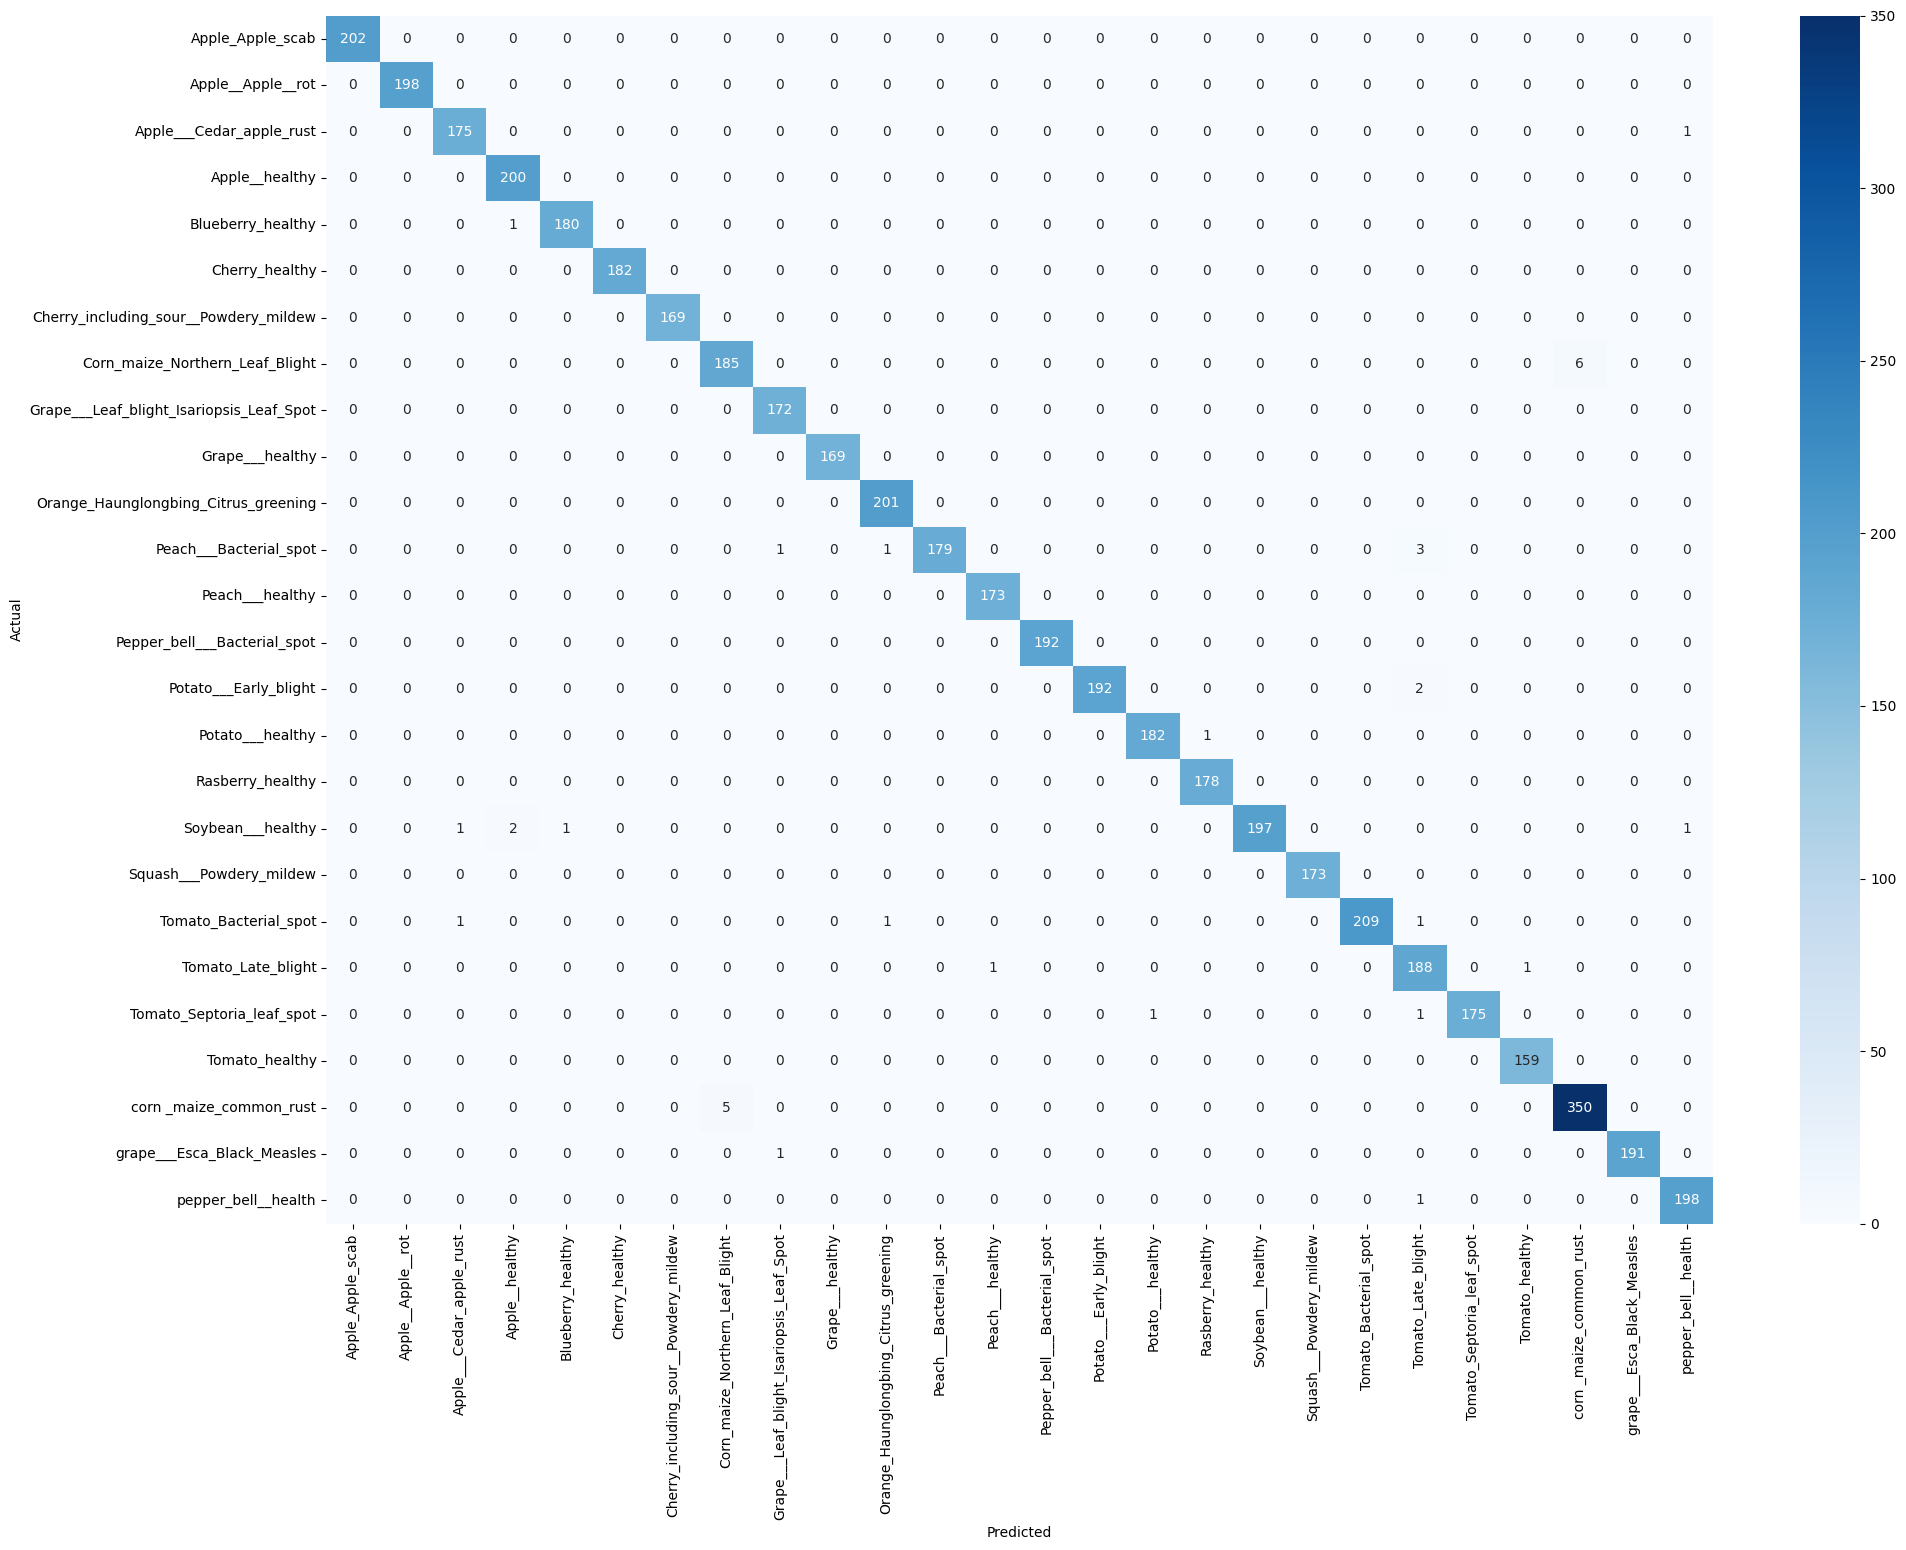

In [17]:
best_model = AutoModelForImageClassification.from_pretrained(best_model_dir).to(DEVICE)
test_metrics, test_labels, test_predictions = evaluate(best_model, test_loader, DEVICE)

with (MODEL_DIR / 'test_metrics.json').open('w') as file:
    json.dump(test_metrics, file, indent=2)

print(json.dumps(test_metrics, indent=2))

class_names = [id_to_label[index] for index in range(len(id_to_label))]
save_confusion_matrix(test_labels, test_predictions, class_names, MODEL_DIR / 'confusion_matrix.png')

## 15. Predict One Leaf Image

In [18]:
def predict_image(image_path: str | Path, model, transform, id_to_label: dict[int, str], device: torch.device, top_k: int = 3):
    model.eval()
    image = load_clean_rgb(Path(image_path))
    pixel_values = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(pixel_values=pixel_values).logits
        probabilities = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]

    top_indices = probabilities.argsort()[::-1][:top_k]
    return [(id_to_label[int(index)], float(probabilities[index])) for index in top_indices]

# Example:
# predict_image('/content/my_leaf.jpg', best_model, eval_transform, id_to_label, DEVICE)

In [19]:
from sklearn.metrics import classification_report

class_names = [id_to_label[index] for index in range(len(id_to_label))]

report = classification_report(
    test_labels,
    test_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0,
)

print(report)

with open(MODEL_DIR / 'classification_report.txt', 'w') as file:
    file.write(report)

                                          precision    recall  f1-score   support

                        Apple_Apple_scab     1.0000    1.0000    1.0000       202
                       Apple__Apple__rot     1.0000    1.0000    1.0000       198
                Apple___Cedar_apple_rust     0.9887    0.9943    0.9915       176
                          Apple__healthy     0.9852    1.0000    0.9926       200
                       Blueberry_healthy     0.9945    0.9945    0.9945       181
                          Cherry_healthy     1.0000    1.0000    1.0000       182
   Cherry_including_sour__Powdery_mildew     1.0000    1.0000    1.0000       169
         Corn_maize_Northern_Leaf_Blight     0.9737    0.9686    0.9711       191
Grape___Leaf_blight_Isariopsis_Leaf_Spot     0.9885    1.0000    0.9942       172
                         Grape___healthy     1.0000    1.0000    1.0000       169
    Orange_Haunglongbing_Citrus_greening     0.9901    1.0000    0.9950       201
               

In [20]:
test_rows = []

for image_path, true_label_id in test_dataset.samples:
    test_rows.append({
        'image_path': str(image_path),
        'true_label': id_to_label[int(true_label_id)],
        'predicted_label': id_to_label[int(test_predictions[len(test_rows)])],
        'correct': int(true_label_id) == int(test_predictions[len(test_rows)]),
    })

predictions_df = pd.DataFrame(test_rows)
predictions_df.to_csv(MODEL_DIR / 'test_predictions.csv', index=False)

display(predictions_df.head())

,image_path,true_label,predicted_label,correct
0,/content/leaf-disease-vit/data/processed/test/...,Apple_Apple_scab,Apple_Apple_scab,True
1,/content/leaf-disease-vit/data/processed/test/...,Apple_Apple_scab,Apple_Apple_scab,True
2,/content/leaf-disease-vit/data/processed/test/...,Apple_Apple_scab,Apple_Apple_scab,True
3,/content/leaf-disease-vit/data/processed/test/...,Apple_Apple_scab,Apple_Apple_scab,True
4,/content/leaf-disease-vit/data/processed/test/...,Apple_Apple_scab,Apple_Apple_scab,True


In [21]:
wrong_df = predictions_df[predictions_df['correct'] == False]

print(f'Wrong predictions: {len(wrong_df)} / {len(predictions_df)}')
display(wrong_df.head(20))

Wrong predictions: 35 / 5004


,image_path,true_label,predicted_label,correct
520,/content/leaf-disease-vit/data/processed/test/...,Apple___Cedar_apple_rust,pepper_bell__health,False
827,/content/leaf-disease-vit/data/processed/test/...,Blueberry_healthy,Apple__healthy,False
1330,/content/leaf-disease-vit/data/processed/test/...,Corn_maize_Northern_Leaf_Blight,corn _maize_common_rust,False
1338,/content/leaf-disease-vit/data/processed/test/...,Corn_maize_Northern_Leaf_Blight,corn _maize_common_rust,False
1375,/content/leaf-disease-vit/data/processed/test/...,Corn_maize_Northern_Leaf_Blight,corn _maize_common_rust,False
1414,/content/leaf-disease-vit/data/processed/test/...,Corn_maize_Northern_Leaf_Blight,corn _maize_common_rust,False
1417,/content/leaf-disease-vit/data/processed/test/...,Corn_maize_Northern_Leaf_Blight,corn _maize_common_rust,False
1489,/content/leaf-disease-vit/data/processed/test/...,Corn_maize_Northern_Leaf_Blight,corn _maize_common_rust,False
2052,/content/leaf-disease-vit/data/processed/test/...,Peach___Bacterial_spot,Tomato_Late_blight,False
2056,/content/leaf-disease-vit/data/processed/test/...,Peach___Bacterial_spot,Grape___Leaf_blight_Isariopsis_Leaf_Spot,False


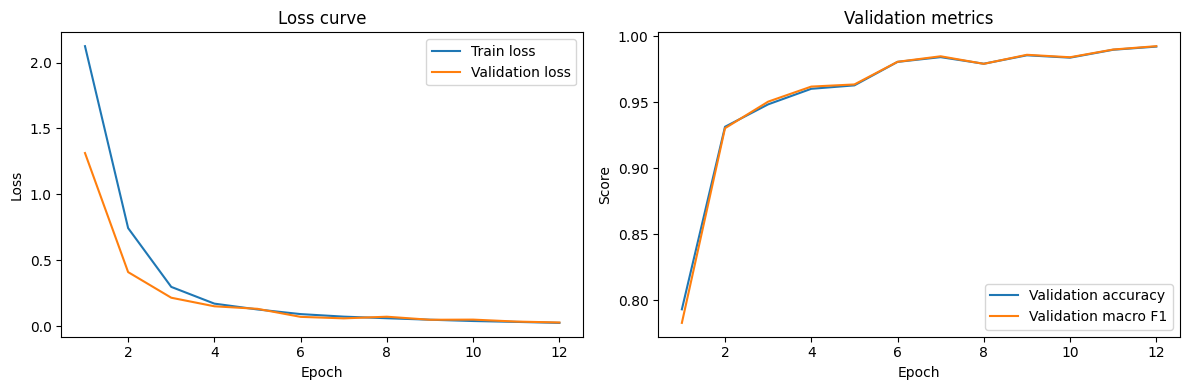

In [22]:
history_df = pd.DataFrame(metrics_history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['val_accuracy'], label='Validation accuracy')
plt.plot(history_df['epoch'], history_df['val_macro_f1'], label='Validation macro F1')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation metrics')
plt.legend()

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_curves.png', dpi=200)
plt.show()

In [23]:
from google.colab import drive
drive.mount('/content/drive')
MODEL_DIR = Path('/content/drive/MyDrive/leaf-disease-vit/outputs/vit_leaf_disease')
AUDIT_DIR = Path('/content/drive/MyDrive/leaf-disease-vit/outputs/data_audit')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [25]:
best_model = AutoModelForImageClassification.from_pretrained(
    MODEL_DIR / 'best_model'
).to(DEVICE)

image_processor = AutoImageProcessor.from_pretrained(
    MODEL_DIR / 'best_model'
)

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'metrics_history': metrics_history,
    'best_val_f1': best_val_f1,
    'best_epoch': best_epoch,
    'epochs_without_improvement': epochs_without_improvement,
}, MODEL_DIR / 'resume_checkpoint.pt')

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/leaf-disease-vit/outputs/vit_leaf_disease/best_model'. Use `repo_type` argument if needed.